In [89]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
pp = Preprocessor()

In [91]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [92]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818
Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [93]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

Genes before Treshold: 18533
count    18533.000000
mean        31.338261
std         83.872808
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [94]:
results_df

,HER2-enriched,Luminal A,Luminal B,AveExpr,F,pvalue,adj_pvalue
CLPTM1L,11.102512,11.135727,11.432034,11.178603,3411.584991,0.000000e+00,0.000000e+00
CENPI,5.470060,5.888030,6.715312,5.789382,1450.712650,0.000000e+00,0.000000e+00
MYO7A,6.271601,6.449378,6.908579,6.404052,1924.652991,0.000000e+00,0.000000e+00
TICAM1,9.053592,8.909586,9.122539,9.029430,3672.081507,0.000000e+00,0.000000e+00
ATRN,11.000081,10.966267,10.703819,10.940783,3599.868581,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
SLC28A2,0.277010,0.242954,0.086340,0.243943,14.846553,1.159021e-09,1.159271e-09
SSX6,0.132164,0.226988,0.328592,0.195638,14.669272,1.503423e-09,1.503666e-09
TMEM229A,0.207897,0.218256,0.103054,0.198622,14.233538,2.848866e-09,2.849174e-09
GADL1,0.142536,0.159804,0.223690,0.175297,13.301483,1.116376e-08,1.116436e-08


In [103]:
N_GENES = 1000
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler = torch_preprocessing.get_data_set(60)



Genes before Treshold: 1003
count    1003.000000
mean        0.929212
std         3.489359
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        42.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [96]:
print(top_genes_limma)

['DSTYK', 'APOM', 'SPN', 'RAB37', 'KAT2B', 'SNX29P2', 'COL8A2', 'PMEPA1', 'NUDC', 'MYL6', 'IMPDH2', 'CEP164', 'PLAC1', 'KLRG1', 'GLI1', 'PAK4', 'SERP1', 'HSPA4', 'ITGA8', 'RAD9A', 'USH2A', 'BCL11A', 'LPL', 'WDR43', 'RPL12', 'TRIM34', 'EIF5B', 'LOC441666', 'TGFBI', 'SLC25A13', 'B3GNT8', 'BBS4', 'HCLS1', 'CENPI', 'MYO7A', 'TICAM1', 'ATRN', 'CD38', 'CBLL1', 'UQCR10', 'ACP2', 'SAPCD2', 'TP63', 'UBE2D1', 'JOSD2', 'SH3BP1', 'ZFAND6', 'TARSL2', 'FKBP7', 'DNAJC1', 'EBNA1BP2', 'BRK1', 'ANXA8', 'FAM208B', 'IL11', 'DAPK3', 'CLPTM1L', 'RAB2B', 'CUL9', 'SNRPE', 'TFE3', 'ALDH7A1', 'HTRA1', 'EFTUD1', 'ITGA6', 'NMT2', 'CMPK2', 'SAE1', 'RIOK1', 'BAD', 'SMCR8', 'KIF20B', 'SAFB2', 'FRZB', 'ADH5', 'ZBED5', 'IQUB', 'UGP2', 'TC2N', 'MTA3', 'CFL1', 'DYNC1I1', 'SYNPO', 'TDG', 'PECR', 'ZNF211', 'SLC8B1', 'GPR75', 'OARD1', 'ZNF575', 'YAF2', 'CHRM3', 'OSGEPL1', 'GPM6B', 'NDUFB3', 'ZNF815P', 'POU3F1', 'HDAC3', 'IGSF9B', 'KIZ', 'RNPC3', 'DZIP1', 'SIGLEC9', 'ZNF605', 'SNRPD1', 'USP7', 'RIPK2', 'BGN', 'UBE2I', 'DDX1

In [97]:
X_scaled.shape

(519, 1000)

In [98]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [59]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")

Train: 415, Val: 52, Test: 52


In [60]:
train_X.shape

torch.Size([415, 1000])

Grid Search for the best Model

In [65]:
from itertools import product

in_features = train_X.shape[1]
output_bias = False
param_grid = {
    "num_nodes": [
        [16], [32], [64], [128],
        [16, 16], [32, 16], [32, 32],
    ],
    "dropout": [0.2, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [128, 256],
}
grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

In [66]:
from pycox.evaluation import EvalSurv

best_score = -1
best_params = None
grid_results = []

val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes, dp, bn, lr, wd, batch_size in grid:
    try:
        net = tt.torchtuples.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=num_nodes,
            out_features=1,
            dropout=dp,
            output_bias=False,
            batch_norm=bn,
        )
        model_gs = CoxPH(net, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))
        
        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=5)]
        model_gs.fit(
            input=train_X,
            target=(train_durations, train_events),
            batch_size=batch_size,
            epochs=100,
            callbacks=callbacks,
            verbose=False,
            val_data=(val_X, (val_durations, val_events)),
            val_batch_size=batch_size
        )
        
        # ← Igual que en Cell 42: compute_baseline_hazards + EvalSurv
        model_gs.compute_baseline_hazards()
        surv_val = model_gs.predict_surv_df(val_X)
        ev = EvalSurv(surv_val, val_durations, val_events, censor_surv='km')
        c_index = ev.concordance_td()

        grid_results.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index
        })

        if c_index > best_score:
            best_score = c_index
            best_params = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación: {best_score:.4f}")
print(f"Mejores parámetros: {best_params}")

Mejor C-index en validación: 0.9561
Mejores parámetros: {'num_nodes': [16], 'dropout': 0.2, 'batch_norm': True, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 256}


Training the Model

In [67]:

out_features = 1
num_nodes    = best_params['num_nodes']
dropout      = best_params['dropout']
batch_norm   = best_params['batch_norm']
lr           = best_params['lr']
weight_decay = best_params['weight_decay']
batch_size   = best_params['batch_size']


net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


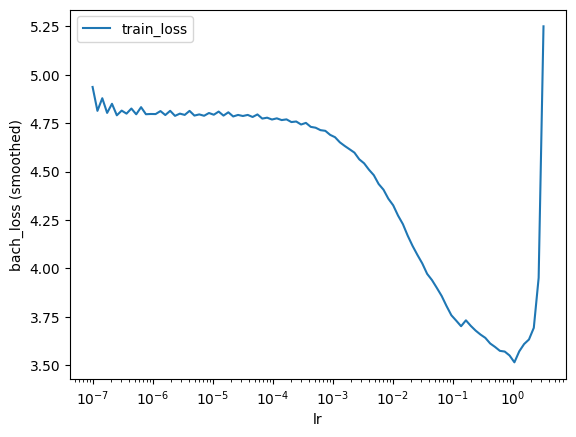

In [68]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [69]:
train_durations.shape

torch.Size([415])

In [70]:
model.optimizer.set_lr(lr)


In [71]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=15)]
verbose = True

In [72]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.9026,	val_loss: 3.0384
1:	[0s / 0s],		train_loss: 4.5920,	val_loss: 3.0101
2:	[0s / 0s],		train_loss: 4.4900,	val_loss: 2.9832
3:	[0s / 0s],		train_loss: 4.3493,	val_loss: 2.9557
4:	[0s / 0s],		train_loss: 4.3499,	val_loss: 2.9285
5:	[0s / 0s],		train_loss: 4.1563,	val_loss: 2.9107
6:	[0s / 0s],		train_loss: 4.0408,	val_loss: 2.8979
7:	[0s / 0s],		train_loss: 3.9400,	val_loss: 2.8900
8:	[0s / 0s],		train_loss: 3.9447,	val_loss: 2.8862
9:	[0s / 0s],		train_loss: 3.8100,	val_loss: 2.8845
10:	[0s / 0s],		train_loss: 3.7353,	val_loss: 2.8799
11:	[0s / 0s],		train_loss: 3.7583,	val_loss: 2.8784
12:	[0s / 0s],		train_loss: 3.5613,	val_loss: 2.8747
13:	[0s / 0s],		train_loss: 3.6322,	val_loss: 2.8744
14:	[0s / 0s],		train_loss: 3.4897,	val_loss: 2.8751
15:	[0s / 0s],		train_loss: 3.4731,	val_loss: 2.8693
16:	[0s / 0s],		train_loss: 3.4496,	val_loss: 2.8702
17:	[0s / 0s],		train_loss: 3.4373,	val_loss: 2.8665
18:	[0s / 0s],		train_loss: 3.2710,	val_loss: 2.8609
19:

(52, 1000)

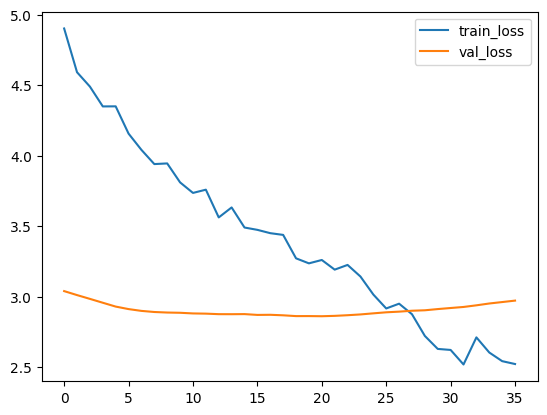

In [73]:
_ = log.plot()
val_X.shape

Log Likehood (The Loss)

In [74]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-2.860007

In [75]:
_ = model.compute_baseline_hazards()

In [76]:
surv = model.predict_surv_df(input=test_X)

In [77]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(275, 52)

Kaplan Meier

In [78]:
risk_nn = model.net(test_X).flatten()

list_risk = []
for i in risk_nn:
    list_risk.append(i.item())



For this group the risk High

For the time 0 the risk group is 26
For the time 12 the risk group is 20
For the time 24 the risk group is 12
For the time 36 the risk group is 8
For the time 48 the risk group is 5
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 21
For the time 24 the risk group is 13
For the time 36 the risk group is 7
For the time 48 the risk group is 4
For the time 60 the risk group is 0


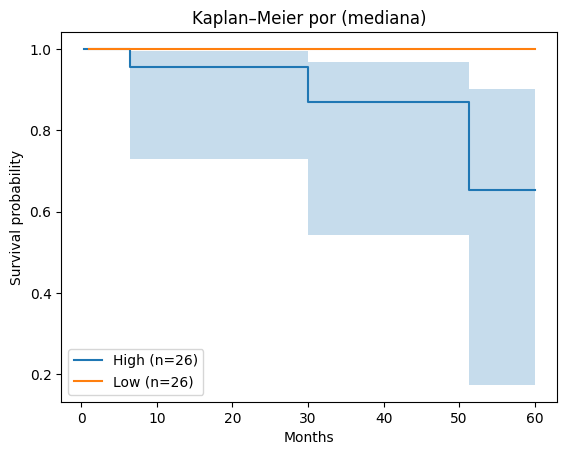

In [79]:
df = pd.DataFrame()

thr = np.median(list_risk)
df["group"] = np.where(risk_nn > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

Log Rank of the Model

In [80]:

time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=2.783, p=0.09528


Prediction of survival of the Patients

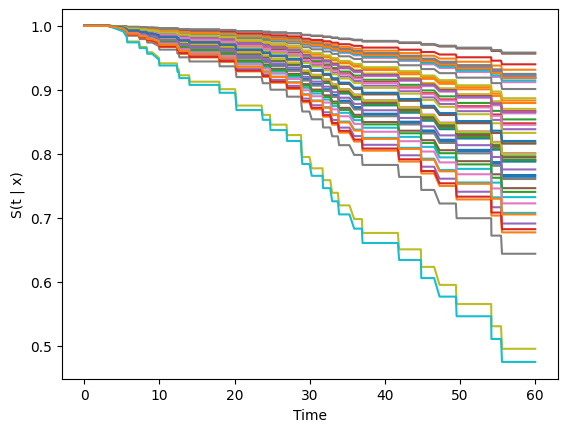

In [81]:
surv.iloc[:, :].plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

In [82]:
test_X = np.array(test_X).astype('float32')
test_durations = np.array(test_durations).flatten()
test_events = np.array(test_events).astype(bool).flatten()

print(f"test_X shape: {test_X.shape}")
print(f"test_durations shape: {test_durations.shape}")
print(f"test_events shape: {test_events.shape}")

test_X shape: (52, 1000)
test_durations shape: (52,)
test_events shape: (52,)


In [83]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [84]:
print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.9583333333333334


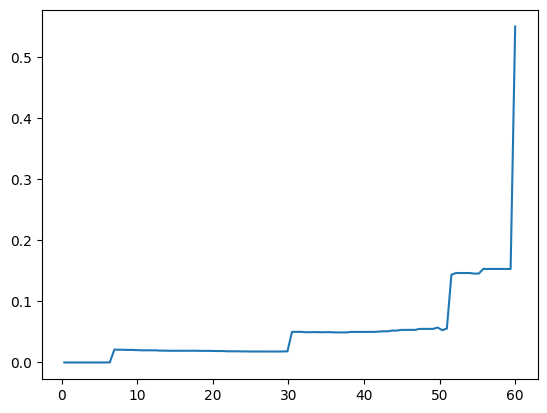

In [85]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [86]:
ev.integrated_brier_score(time_grid=time_grid)

0.04937170468317167

In [106]:
ev.integrated_nbll(time_grid)
ci_test_deepsurv = ev.concordance_td()
ibs_deepsurv     = ev.integrated_brier_score(time_grid)

In [105]:
import shap
from sklearn.utils import resample

N_BOOTSTRAP = 50
gene_shap_records = {gene: [] for gene in torch_preprocessing.genes_expression}

for i in range(N_BOOTSTRAP):
    # 1. Resamplear train
    idx = resample(range(len(train_X)), random_state=i)
    X_boot = train_X[idx]
    dur_boot = train_durations[idx]
    ev_boot = train_events[idx]

    # 2. Entrenar modelo con best_params
    net_boot = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=best_params['num_nodes'],
        out_features=1,
        batch_norm=best_params['batch_norm'],
        dropout=best_params['dropout'],
        output_bias=False
    )
    model_boot = CoxPH(net_boot, tt.torchtuples.optim.Adam(
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay']
    ))
    model_boot.fit(X_boot, (dur_boot, ev_boot),
                   batch_size=best_params['batch_size'],
                   epochs=100, verbose=False)

    # 3. Calcular SHAP con GradientExplainer (diseñado para redes PyTorch)
    background  = torch.tensor(train_X[:100], dtype=torch.float32)
    test_tensor = torch.tensor(test_X,        dtype=torch.float32)

    explainer    = shap.GradientExplainer(model_boot.net, background)
    shap_vals_np = explainer.shap_values(test_tensor)

    # shap_values devuelve lista si hay múltiples salidas → coger el primer elemento
    if isinstance(shap_vals_np, list):
        shap_vals_np = shap_vals_np[0]

    # 4. Guardar importancia media por gen
    mean_abs = np.abs(shap_vals_np).mean(axis=0)
    for j, gene in enumerate(genes_expression):
        gene_shap_records[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} done")

# 5. Calcular estabilidad y relevancia
bootstrap_df = pd.DataFrame({
    'gene':      genes_expression,
    'mean_shap': [np.mean(gene_shap_records[g]) for g in genes_expression],
    'std_shap':  [np.std(gene_shap_records[g])  for g in genes_expression],
    'stability': [np.mean(np.array(gene_shap_records[g]) > 0)
                  for g in genes_expression],
}).sort_values('mean_shap', ascending=False)

bootstrap_df.head(20)

Bootstrap 1/50 done
Bootstrap 2/50 done
Bootstrap 3/50 done
Bootstrap 4/50 done
Bootstrap 5/50 done
Bootstrap 6/50 done
Bootstrap 7/50 done
Bootstrap 8/50 done
Bootstrap 9/50 done
Bootstrap 10/50 done
Bootstrap 11/50 done
Bootstrap 12/50 done
Bootstrap 13/50 done
Bootstrap 14/50 done
Bootstrap 15/50 done
Bootstrap 16/50 done
Bootstrap 17/50 done
Bootstrap 18/50 done
Bootstrap 19/50 done
Bootstrap 20/50 done
Bootstrap 21/50 done
Bootstrap 22/50 done
Bootstrap 23/50 done
Bootstrap 24/50 done
Bootstrap 25/50 done
Bootstrap 26/50 done
Bootstrap 27/50 done
Bootstrap 28/50 done
Bootstrap 29/50 done
Bootstrap 30/50 done
Bootstrap 31/50 done
Bootstrap 32/50 done
Bootstrap 33/50 done
Bootstrap 34/50 done
Bootstrap 35/50 done
Bootstrap 36/50 done
Bootstrap 37/50 done
Bootstrap 38/50 done
Bootstrap 39/50 done
Bootstrap 40/50 done
Bootstrap 41/50 done
Bootstrap 42/50 done
Bootstrap 43/50 done
Bootstrap 44/50 done
Bootstrap 45/50 done
Bootstrap 46/50 done
Bootstrap 47/50 done
Bootstrap 48/50 done
B

,gene,mean_shap,std_shap,stability
269,CCDC25,0.043649,0.022608,1.0
836,HSD11B2,0.042233,0.019154,1.0
640,QARS1,0.042031,0.022698,1.0
949,SYS1-DBNDD2,0.038519,0.020631,1.0
499,F2RL2,0.038298,0.020288,1.0
900,TOMM70A,0.037889,0.019516,1.0
941,SNX10,0.036872,0.018432,1.0
255,OSBPL9,0.036051,0.020228,1.0
845,CDC42BPG,0.035505,0.017390,1.0
422,NOV,0.035219,0.020612,1.0


In [ ]:
param_grid_cn = {
    "num_nodes":    [[16], [32], [64], [128], [256]],  # ← 1 sola capa
    "dropout":      [0.2, 0.4],
    "batch_norm":   [True, False],
    "lr":           [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size":   [128, 256],
}
grid_cn = list(product(
    param_grid_cn["num_nodes"],
    param_grid_cn["dropout"],
    param_grid_cn["batch_norm"],
    param_grid_cn["lr"],
    param_grid_cn["weight_decay"],
    param_grid_cn["batch_size"],
))

best_score_cn  = -1
best_params_cn = None
grid_results_cn = []

for num_nodes, dp, bn, lr, wd, batch_size in grid_cn:
    try:
        net_cn = tt.torchtuples.practical.MLPVanilla(
            in_features  = in_features,
            num_nodes    = num_nodes,       # lista de 1 elemento
            out_features = 1,
            dropout      = dp,
            output_bias  = False,
            batch_norm   = bn,
        )
        model_cn_gs = CoxPH(net_cn, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))

        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=5)]
        model_cn_gs.fit(
            input      = train_X,
            target     = (train_durations, train_events),
            batch_size = batch_size,
            epochs     = 100,
            callbacks  = callbacks,
            verbose    = False,
            val_data   = (val_X, (val_durations, val_events)),
            val_batch_size = batch_size,
        )

        model_cn_gs.compute_baseline_hazards()
        surv_val_cn = model_cn_gs.predict_surv_df(val_X)
        ev_cn_gs    = EvalSurv(surv_val_cn, val_durations, val_events, censor_surv='km')
        c_index_cn  = ev_cn_gs.concordance_td()

        grid_results_cn.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index_cn
        })

        if c_index_cn > best_score_cn:
            best_score_cn  = c_index_cn
            best_params_cn = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación (Cox-nnet): {best_score_cn:.4f}")
print(f"Mejores parámetros: {best_params_cn}")

Mejor C-index en validación (Cox-nnet): 0.9386
Mejores parámetros: {'num_nodes': [16], 'dropout': 0.4, 'batch_norm': True, 'lr': 0.001, 'weight_decay': 0.001, 'batch_size': 256}


In [ ]:
net_cn = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=best_params_cn['num_nodes'],
    out_features=1, batch_norm=best_params_cn['batch_norm'],
    dropout=best_params_cn['dropout'], output_bias=False,
)
model_cn = CoxPH(net_cn, tt.torchtuples.optim.Adam(
    lr=best_params_cn['lr'], weight_decay=best_params_cn['weight_decay']
))
model_cn.fit(
    input=train_X, target=(train_durations, train_events),
    batch_size=best_params_cn['batch_size'], epochs=200, verbose=True,
    callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=15)],
    val_data=(val_X, (val_durations, val_events)),
)

model_cn.compute_baseline_hazards()
surv_cn = model_cn.predict_surv_df(test_X)
ev_cn   = EvalSurv(surv_cn, test_durations, test_events, censor_surv='km')

ci_test_coxnnet = ev_cn.concordance_td()


0:	[0s / 0s],		train_loss: 5.1374,	val_loss: 3.3026
1:	[0s / 0s],		train_loss: 4.6975,	val_loss: 3.1824
2:	[0s / 0s],		train_loss: 4.4782,	val_loss: 3.1357
3:	[0s / 0s],		train_loss: 4.0713,	val_loss: 3.1616
4:	[0s / 0s],		train_loss: 3.9828,	val_loss: 3.1823
5:	[0s / 0s],		train_loss: 3.9446,	val_loss: 3.1679
6:	[0s / 0s],		train_loss: 3.8300,	val_loss: 3.1454
7:	[0s / 0s],		train_loss: 3.6725,	val_loss: 3.1174
8:	[0s / 0s],		train_loss: 3.4403,	val_loss: 3.0812
9:	[0s / 0s],		train_loss: 3.5456,	val_loss: 3.0505
10:	[0s / 0s],		train_loss: 3.3475,	val_loss: 3.0427
11:	[0s / 0s],		train_loss: 3.4112,	val_loss: 3.0350
12:	[0s / 0s],		train_loss: 3.2203,	val_loss: 3.0375
13:	[0s / 0s],		train_loss: 3.1532,	val_loss: 3.0484
14:	[0s / 0s],		train_loss: 2.9971,	val_loss: 3.0839
15:	[0s / 0s],		train_loss: 3.0943,	val_loss: 3.1297
16:	[0s / 0s],		train_loss: 2.8313,	val_loss: 3.1659
17:	[0s / 0s],		train_loss: 3.0807,	val_loss: 3.1825
18:	[0s / 0s],		train_loss: 3.0033,	val_loss: 3.1803
19:

In [ ]:
print(f"\nC-index test  DeepSurv : {ev.concordance_td():.4f}  capas: {best_params['num_nodes']}")
print(f"C-index test  Cox-nnet : {ci_test_coxnnet:.4f}  capas: {best_params_cn['num_nodes']}")


C-index test  DeepSurv : 0.9583  capas: [16]
C-index test  Cox-nnet : 0.8750  capas: [16]
